# Image Preprocessing Methods

This notebook demonstrates common image preprocessing techniques used in computer vision and medical imaging tasks.

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

def show_gray(img, title="Image"):
    plt.figure(figsize=(8, 5))
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def compare_images(images, titles, cols=3):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 4, rows * 4))
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, i)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_histogram(img, title="Histogram"):
    plt.figure(figsize=(7, 4))
    plt.hist(img.ravel(), bins=256, range=[0, 256])
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

## 1. Load Image

Let's load a sample image for preprocessing.

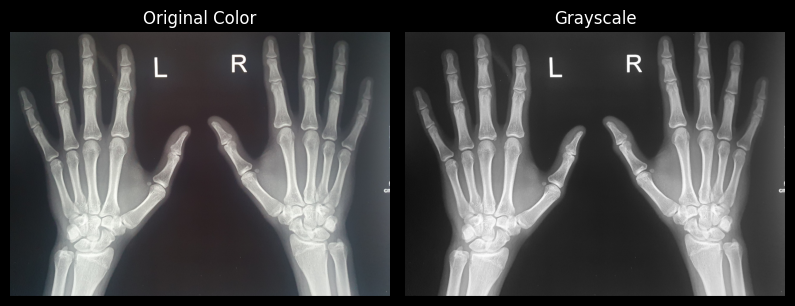

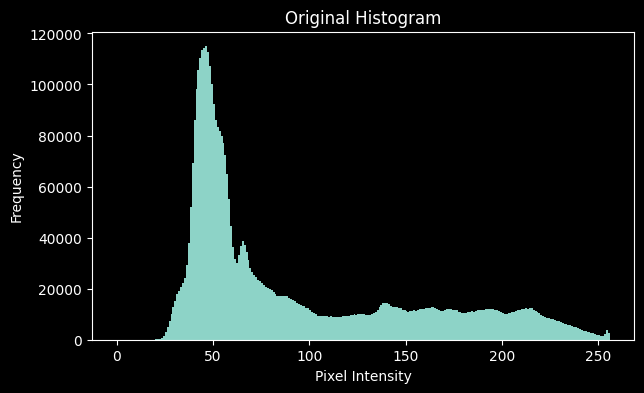

In [53]:
image_path = "wrist.jpg"

img_color = cv2.imread(image_path)

if img_color is None:
    print("Image not found. Using a generated test image instead.")
    img_color = np.zeros((400, 600, 3), dtype=np.uint8)
    for i in range(400):
        for j in range(600):
            img_color[i, j] = [int(100 + 50 * np.sin(i/20) + 30 * np.cos(j/30)),
                               int(120 + 40 * np.cos(i/25)),
                               int(80 + 60 * np.sin(j/20))]
    noise = np.random.randint(0, 30, img_color.shape, dtype=np.uint8)
    img_color = cv2.add(img_color, noise)

img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
compare_images([img_color, img_gray], ["Original Color", "Grayscale"])
plot_histogram(img_gray, "Original Histogram")

## 2. Resizing

Resizing changes image dimensions. Different interpolation methods trade off speed vs quality.

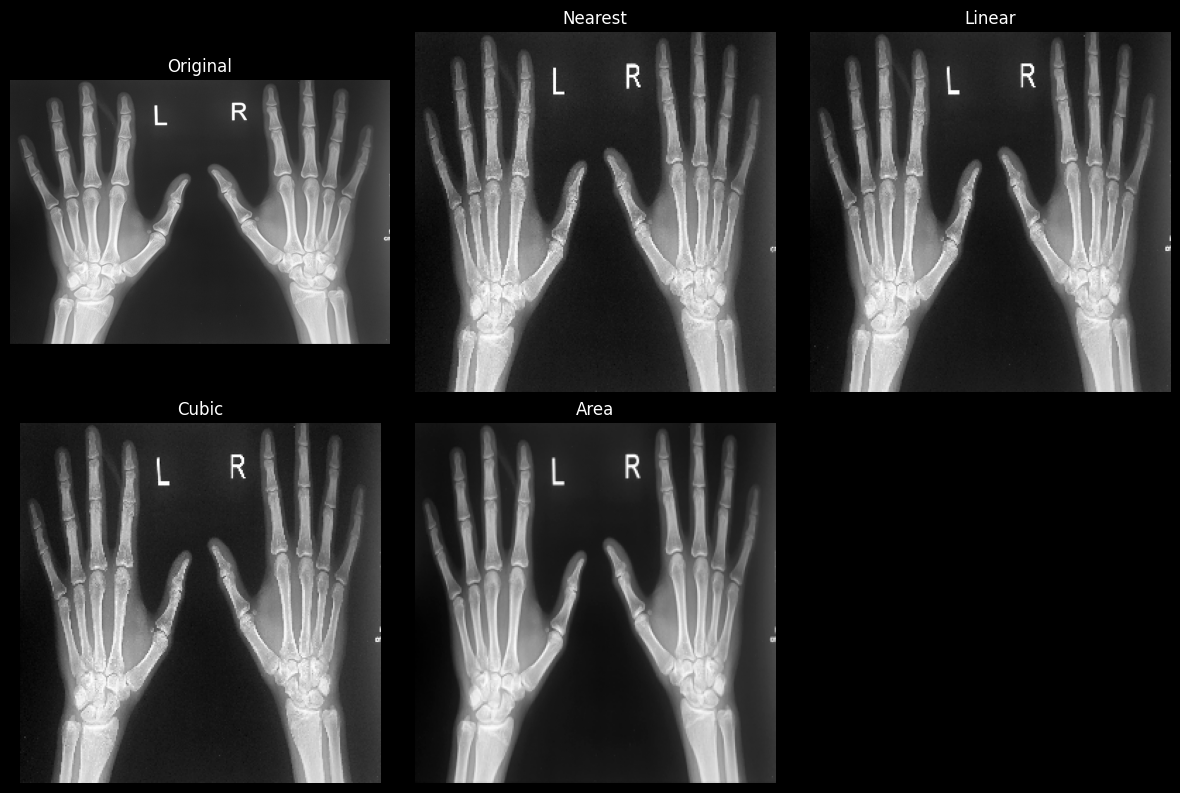

In [54]:
resized_nearest = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_NEAREST)
resized_linear = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_LINEAR)
resized_cubic = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_CUBIC)
resized_area = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_AREA)

compare_images(
    [img_gray, resized_nearest, resized_linear, resized_cubic, resized_area],
    ["Original", "Nearest", "Linear", "Cubic", "Area"],
    cols=3
)

### Task: Resize to 128x128 and 512x512, compare results

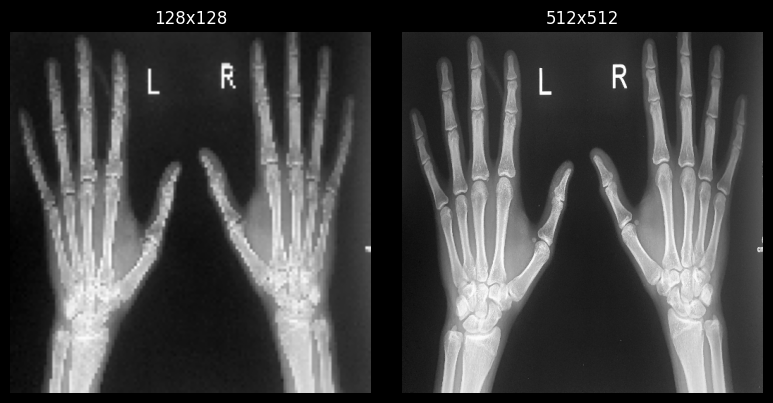

In [55]:
small = cv2.resize(img_gray, (128, 128), interpolation=cv2.INTER_LINEAR)
large = cv2.resize(img_gray, (512, 512), interpolation=cv2.INTER_LINEAR)
compare_images([small, large], ["128x128", "512x512"], cols=2)

## 3. Normalization and Standardization

Normalization scales pixel values to [0, 1]. Standardization centers around mean with unit variance.

Original: min=9.00, max=255.00
Min-Max: min=0.0000, max=1.0000
Standardized: mean=0.000000, std=1.0000


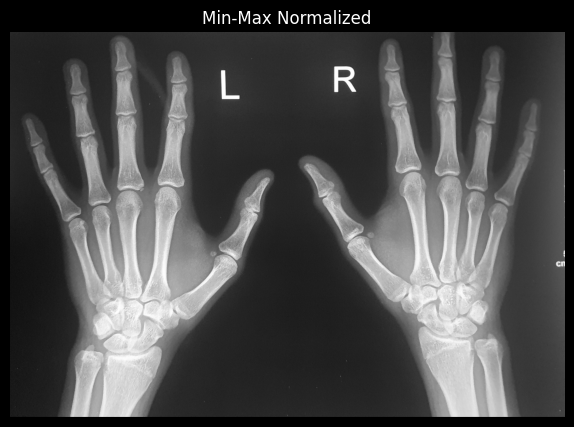

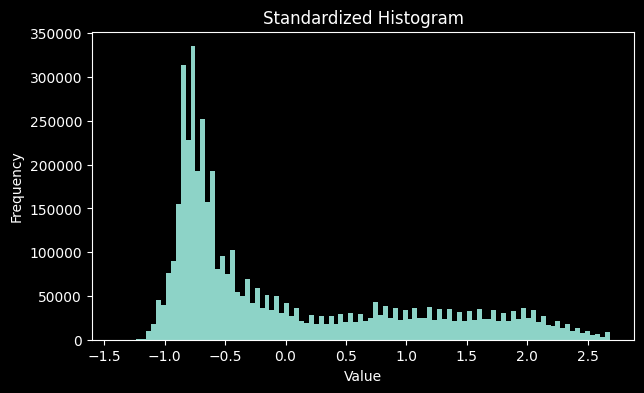

In [56]:
img_float = img_gray.astype(np.float32)

min_val, max_val = img_float.min(), img_float.max()
minmax = (img_float - min_val) / (max_val - min_val + 1e-8)

mean_val, std_val = img_float.mean(), img_float.std()
standardized = (img_float - mean_val) / (std_val + 1e-8)

print(f"Original: min={min_val:.2f}, max={max_val:.2f}")
print(f"Min-Max: min={minmax.min():.4f}, max={minmax.max():.4f}")
print(f"Standardized: mean={standardized.mean():.6f}, std={standardized.std():.4f}")

show_gray(minmax, "Min-Max Normalized")
plt.figure(figsize=(7,4))
plt.hist(standardized.ravel(), bins=100)
plt.title("Standardized Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

## 4. Contrast Stretching

Expands a narrow intensity range to use the full [0, 255] range.

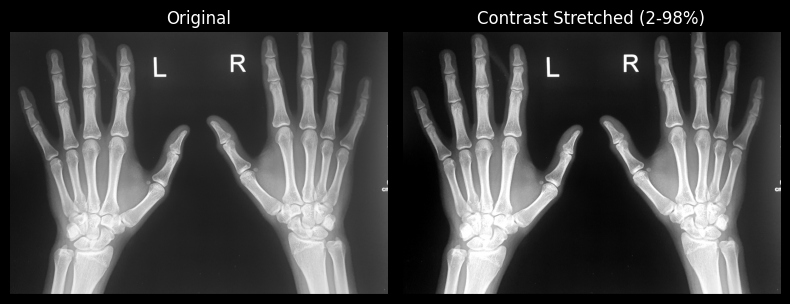

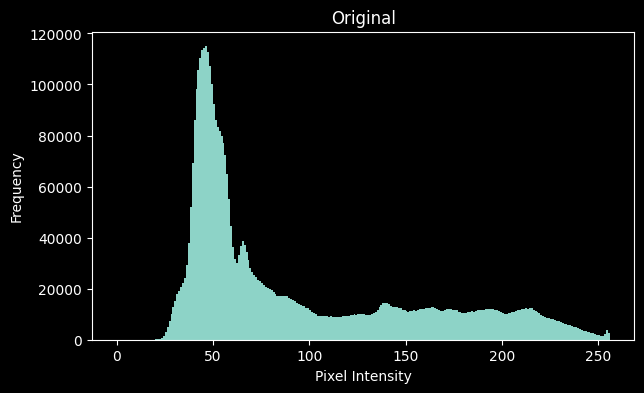

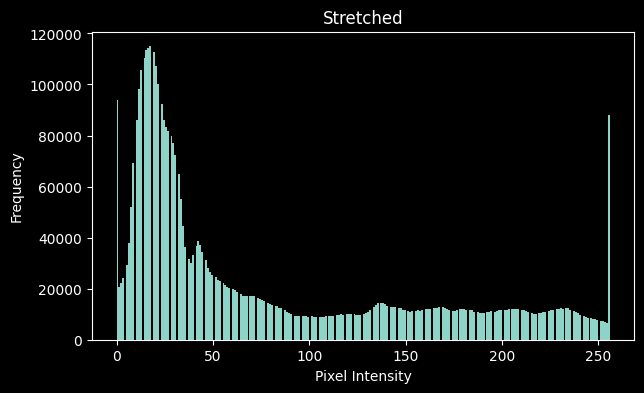

In [57]:
p2, p98 = np.percentile(img_gray, (2, 98))
stretched = np.clip((img_gray - p2) * 255.0 / (p98 - p2 + 1e-8), 0, 255).astype(np.uint8)

compare_images([img_gray, stretched], ["Original", "Contrast Stretched (2-98%)"], cols=2)
plot_histogram(img_gray, "Original")
plot_histogram(stretched, "Stretched")

### Task: Try different percentile pairs

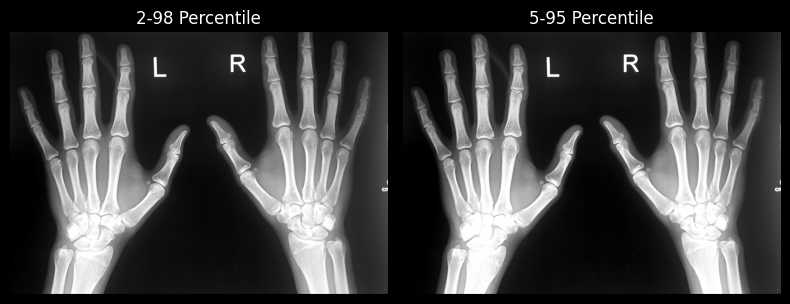

In [58]:
p5, p95 = np.percentile(img_gray, (5, 95))
stretched_5_95 = np.clip((img_gray - p5) * 255.0 / (p95 - p5 + 1e-8), 0, 255).astype(np.uint8)
compare_images([stretched, stretched_5_95], ["2-98 Percentile", "5-95 Percentile"], cols=2)

## 5. Histogram Equalization

Redistributes pixel intensities to make histogram more uniform, improving global contrast.

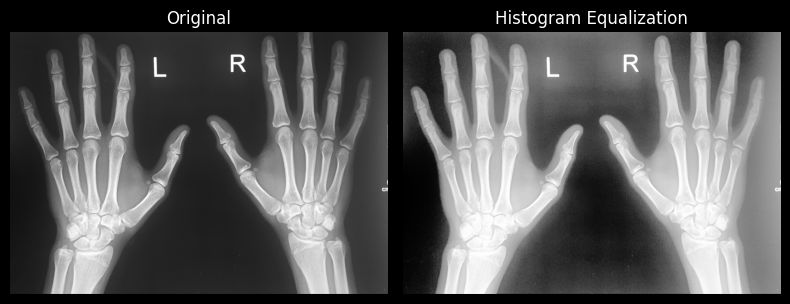

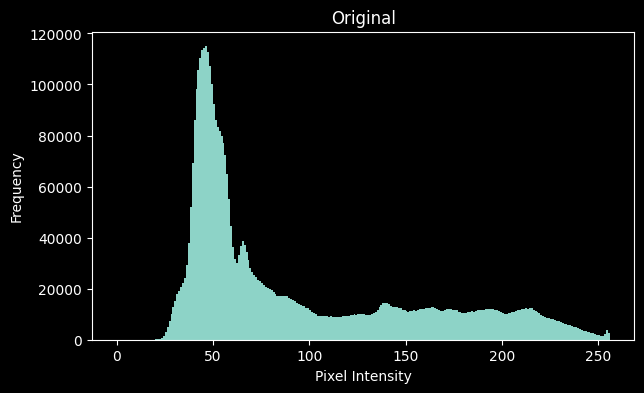

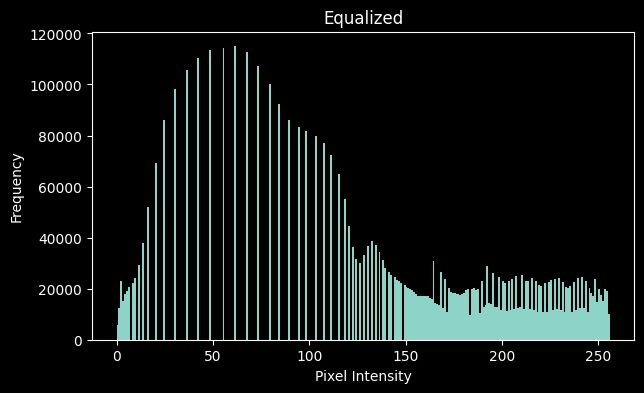

In [59]:
hist_eq = cv2.equalizeHist(img_gray)

compare_images([img_gray, hist_eq], ["Original", "Histogram Equalization"], cols=2)
plot_histogram(img_gray, "Original")
plot_histogram(hist_eq, "Equalized")

## 6. CLAHE (Contrast Limited Adaptive Histogram Equalization)

CLAHE improves local contrast by processing small tiles, with clip limit to prevent noise amplification.

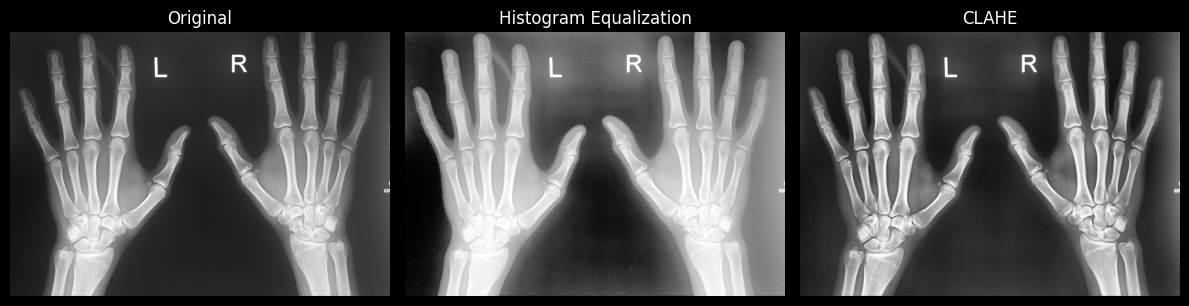

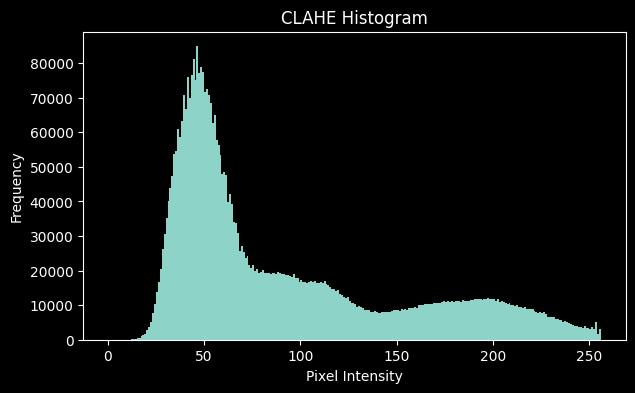

In [60]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

compare_images(
    [img_gray, hist_eq, img_clahe],
    ["Original", "Histogram Equalization", "CLAHE"],
    cols=3
)
plot_histogram(img_clahe, "CLAHE Histogram")

### Task: Try different CLAHE parameters

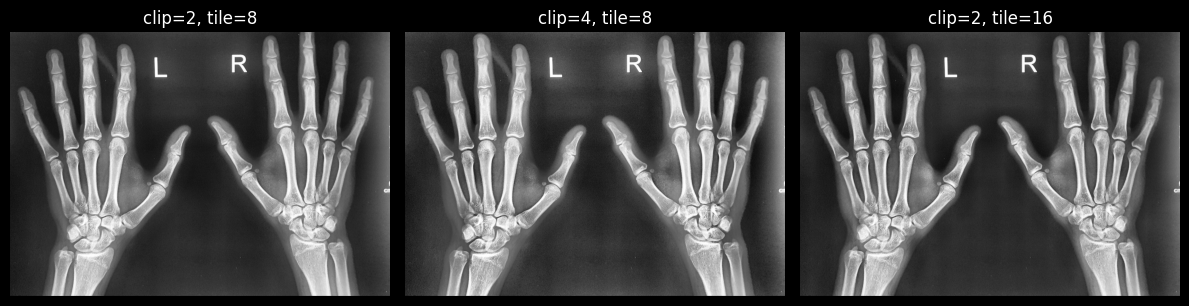

In [61]:
clahe_strong = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8)).apply(img_gray)
clahe_large = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16)).apply(img_gray)

compare_images([img_clahe, clahe_strong, clahe_large], 
                ["clip=2, tile=8", "clip=4, tile=8", "clip=2, tile=16"], cols=3)

## 7. Gamma Correction

Nonlinear brightness adjustment. Gamma < 1 brightens dark regions, gamma > 1 darkens.

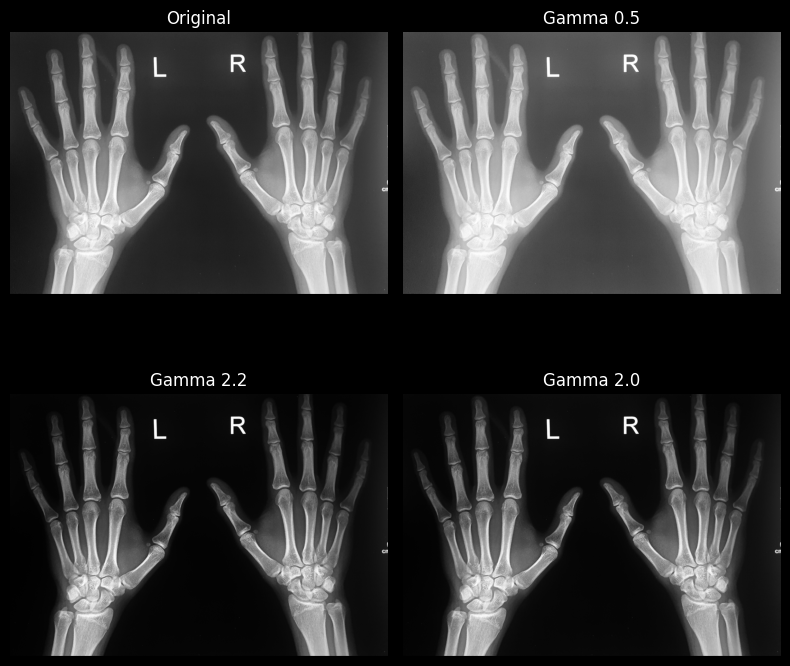

In [72]:
def gamma_correction(image, gamma=1.0):
    image_norm = image / 255.0
    corrected = np.power(image_norm, gamma)
    corrected = np.clip(corrected * 255, 0, 255).astype(np.uint8)
    return corrected

gamma_05 = gamma_correction(img_gray, 0.5)
gamma_15 = gamma_correction(img_gray, 2.2)
gamma_20 = gamma_correction(img_gray, 2.0)

compare_images(
    [img_gray, gamma_05, gamma_15, gamma_20],
    ["Original", "Gamma 0.5", "Gamma 2.2", "Gamma 2.0"],
    cols=2
)

## 8. Log Transformation

Expands dark values and compresses bright values, useful for enhancing dark regions.

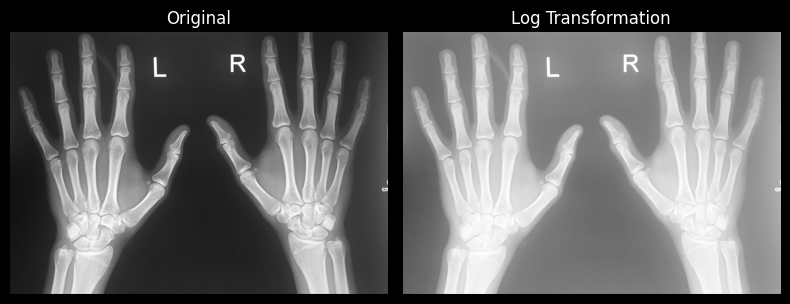

In [63]:
img_float = img_gray.astype(np.float32)
c = 255 / np.log(1 + np.max(img_float))
log_img = c * np.log(1 + img_float)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

compare_images([img_gray, log_img], ["Original", "Log Transformation"], cols=2)

## 9. Denoising Filters

Various filters for noise reduction with different trade-offs.

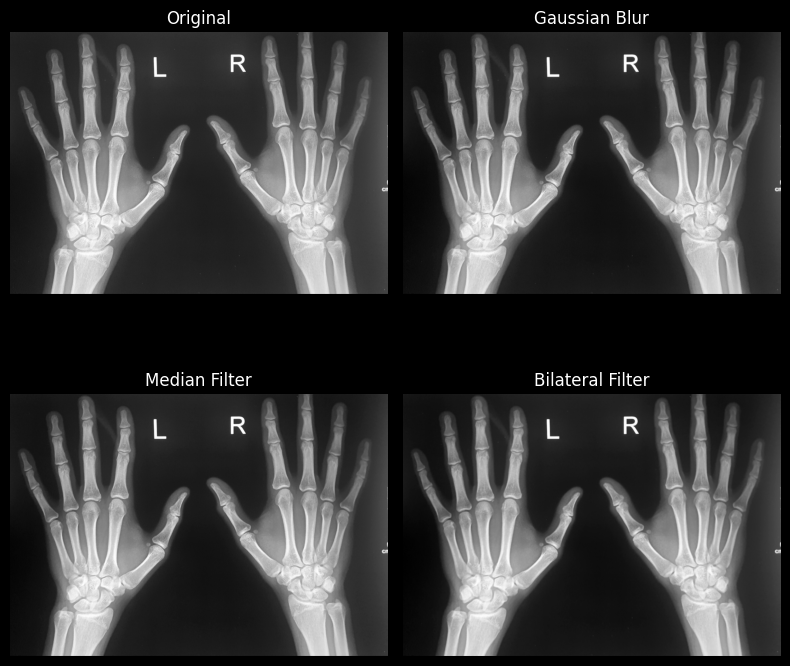

In [64]:
gaussian = cv2.GaussianBlur(img_gray, (5, 5), 0)
median = cv2.medianBlur(img_gray, 5)
bilateral = cv2.bilateralFilter(img_gray, 9, 75, 75)

compare_images(
    [img_gray, gaussian, median, bilateral],
    ["Original", "Gaussian Blur", "Median Filter", "Bilateral Filter"],
    cols=2
)

### Task: Add synthetic noise and compare filters

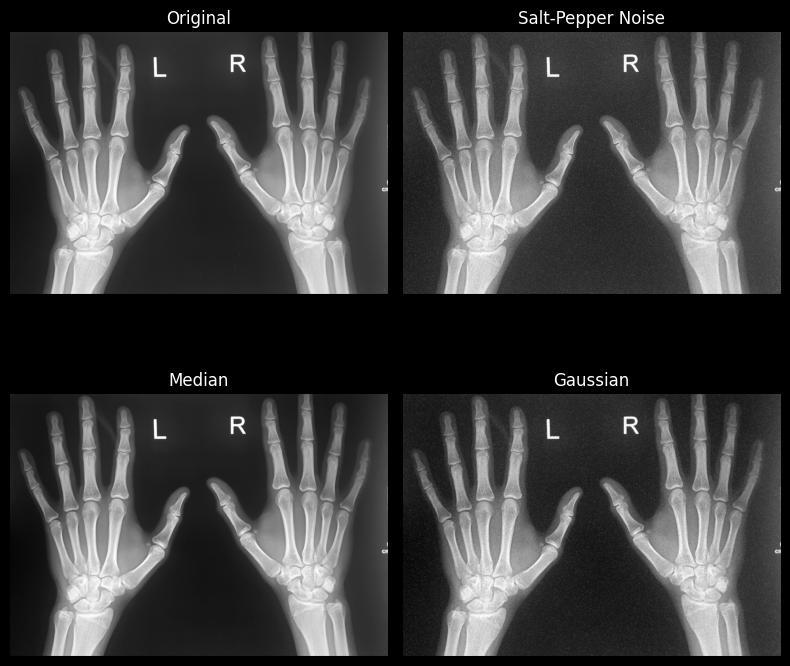

In [65]:
noisy = img_gray.copy()
rng = np.random.default_rng(42)
noise_density = 0.02
salt = rng.random(img_gray.shape) < noise_density
pepper = rng.random(img_gray.shape) < noise_density
noisy[salt] = 255
noisy[pepper] = 0

denoised_median = cv2.medianBlur(noisy, 5)
denoised_gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)
denoised_bilateral = cv2.bilateralFilter(noisy, 9, 75, 75)

compare_images(
    [img_gray, noisy, denoised_median, denoised_gaussian],
    ["Original", "Salt-Pepper Noise", "Median", "Gaussian"],
    cols=2
)

## 10. Sharpening

Enhances edges and fine details using unsharp masking.

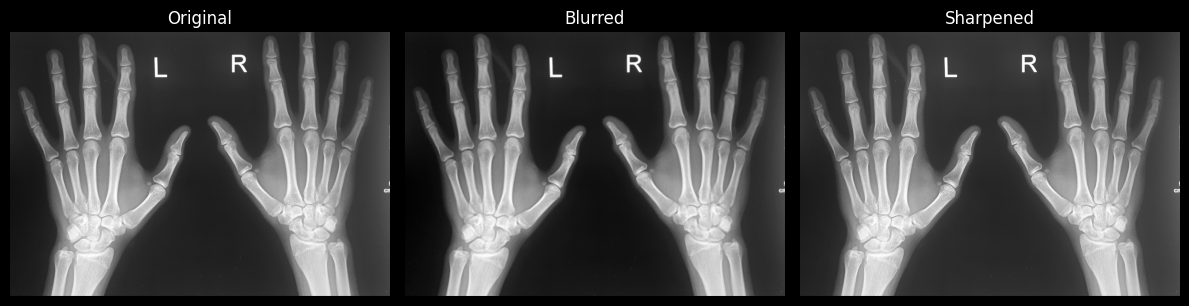

In [66]:
blurred = cv2.GaussianBlur(img_gray, (9, 9), 2.0)
sharpened = cv2.addWeighted(img_gray, 1.5, blurred, -0.5, 0)

compare_images([img_gray, blurred, sharpened], ["Original", "Blurred", "Sharpened"], cols=3)

## 11. Thresholding

Converts grayscale to binary based on intensity threshold.

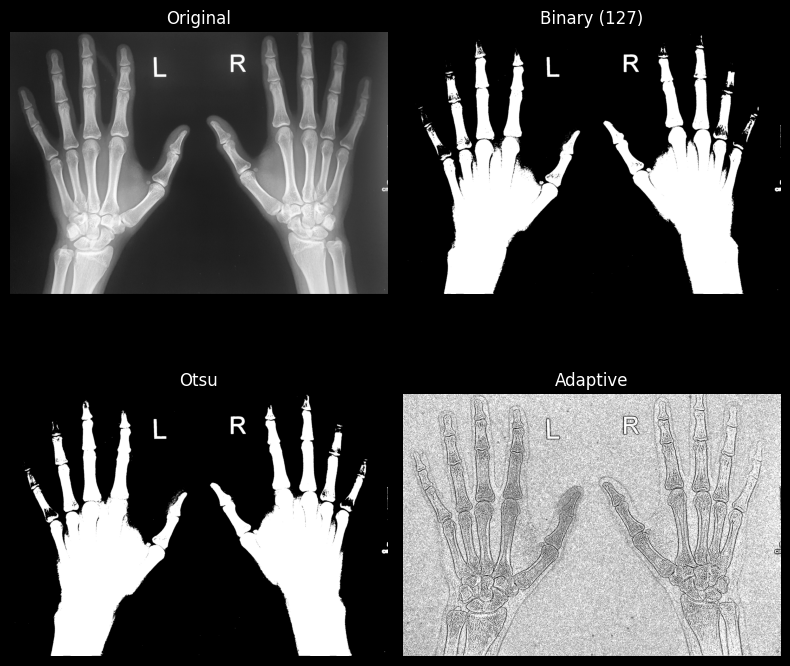

In [67]:
_, th_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
_, th_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
th_adaptive = cv2.adaptiveThreshold(
    img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)

compare_images(
    [img_gray, th_binary, th_otsu, th_adaptive],
    ["Original", "Binary (127)", "Otsu", "Adaptive"],
    cols=2
)

## 12. Color Space Conversion

Different color spaces isolate different image properties.

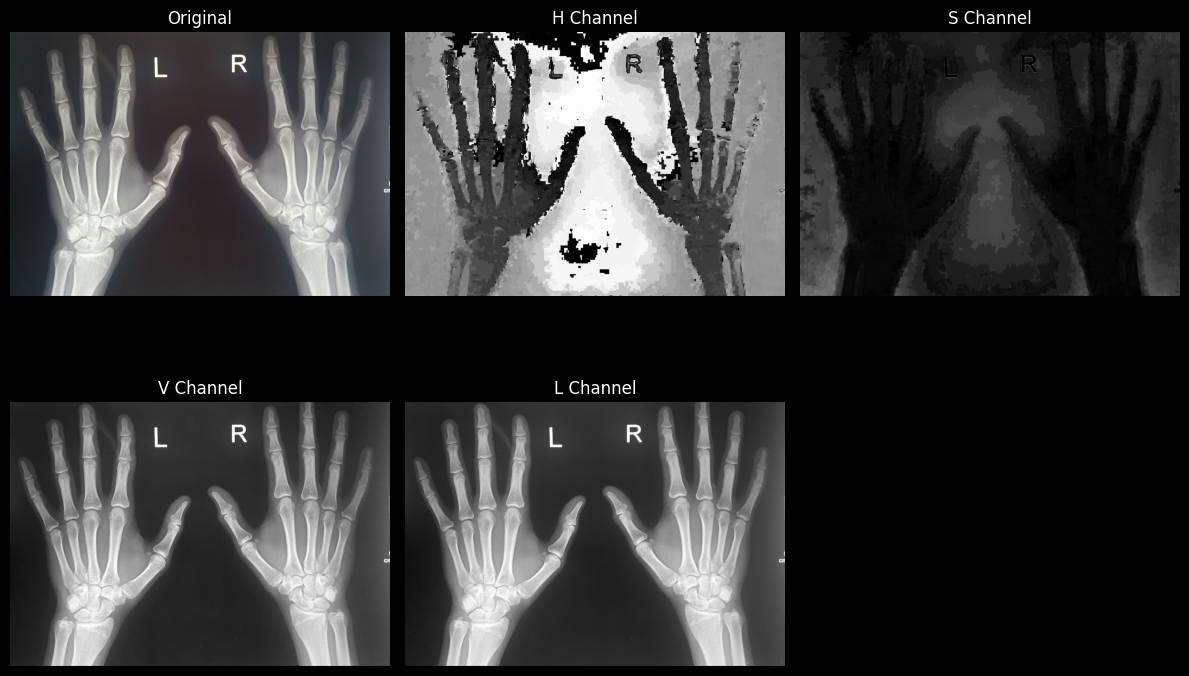

In [68]:
hsv = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img_color, cv2.COLOR_BGR2LAB)

h, s, v = cv2.split(hsv)
l, a, b = cv2.split(lab)

compare_images(
    [img_color, h, s, v, l],
    ["Original", "H Channel", "S Channel", "V Channel", "L Channel"],
    cols=3
)

### Task: Apply CLAHE to different channels

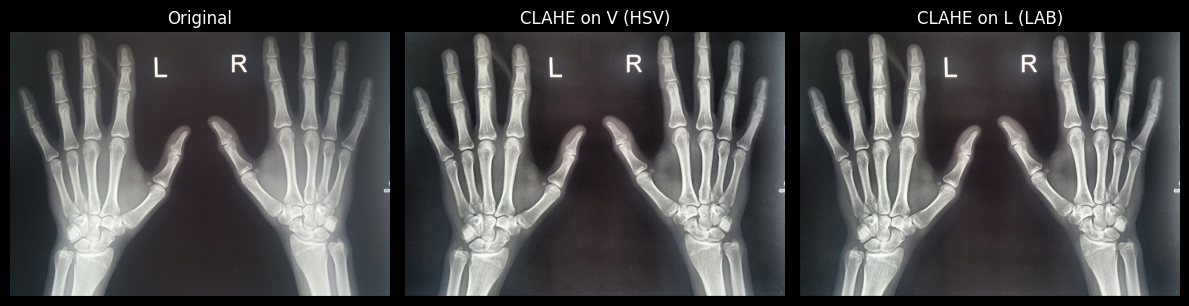

In [69]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

v_clahe = clahe.apply(v)
l_clahe = clahe.apply(l)

hsv_clahe = cv2.merge([h, s, v_clahe])
lab_clahe = cv2.merge([l_clahe, a, b])

color_v_clahe = cv2.cvtColor(hsv_clahe, cv2.COLOR_HSV2BGR)
color_l_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

compare_images(
    [img_color, color_v_clahe, color_l_clahe],
    ["Original", "CLAHE on V (HSV)", "CLAHE on L (LAB)"],
    cols=3
)

## 13. Preprocessing Pipeline Example

Combining multiple preprocessing steps for a complete pipeline.

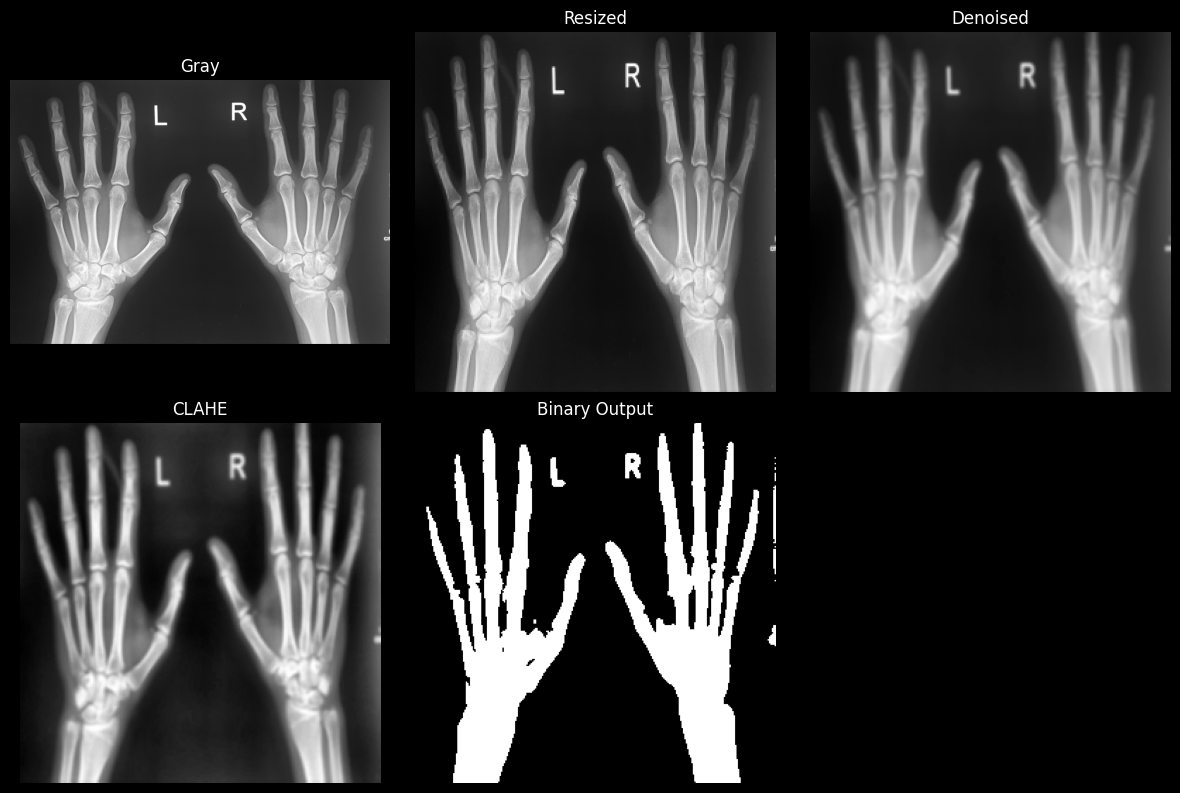

In [70]:
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
resized = cv2.resize(gray, (256, 256), interpolation=cv2.INTER_AREA)
denoised = cv2.GaussianBlur(resized, (5, 5), 0)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(denoised)
_, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

compare_images(
    [gray, resized, denoised, enhanced, binary],
    ["Gray", "Resized", "Denoised", "CLAHE", "Binary Output"],
    cols=3
)

## Summary

Key preprocessing methods:
- **Resizing**: Use INTER_AREA for shrinking, INTER_CUBIC for enlarging
- **Normalization**: For ML pipelines, scale to [0,1]
- **CLAHE**: Best for local contrast in medical images
- **Gamma correction**: Good for dark region enhancement
- **Median filter**: Best for salt-and-pepper noise
- **Bilateral filter**: Best for edge-preserving smoothing
- **Otsu thresholding**: Automatically finds optimal threshold
- **Color spaces**: LAB/HSV useful for illumination-invariant processing